In [1]:
%load_ext autoreload
%autoreload 2

In [66]:
from pdf2image import convert_from_path

yellow_book_path = "data/the_yellow_book.pdf"
images = convert_from_path(yellow_book_path)

In [67]:
samples = images[19:21]

## Preprocess

In [ ]:
from pipeline.preprocess import run_preprocess
from pipeline.preprocess_transforms import binerize_images, canny_images

In [87]:
preprocessed_images_for_ocr, preprocessed_images_for_table_rec, layout_result = run_preprocess(samples, binerize_images, canny_images)


Recognizing layout: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


## Recognize Text

In [97]:
from pipeline.ocr import recognize_text

In [100]:
recognized_texts = recognize_text(preprocessed_images_for_ocr)

Recognizing Text: 100%|██████████| 85/85 [00:27<00:00,  3.05it/s]


## Recognize Tables

In [90]:
from pipeline.table_recognition import run_table_recognition

## Hough

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [126]:
canny_img = np.array(preprocessed_images_for_table_rec[0])
def find_vertical_lines(img: np.ndarray, num_lines: int = 0, angle_tolerance_degrees: float = 10):
    vertical_lines = []
    lines = cv2.HoughLines(img, 1, np.pi / 180, 150) # Increased threshold to find stronger lines
    if lines is not None:
        for line in lines:
            rho, theta = line[0]

            # Convert angle to degrees for easier interpretation and filtering
            angle_deg = np.degrees(theta)

        # Normalize angle to be within [0, 180) for consistency
        if angle_deg < 0:
            angle_deg += 180 # Not strictly necessary if using abs, but good for understanding

        # Check if the line is vertical within the tolerance
        # Vertical lines in Hough space typically have theta close to 0 or 180 degrees.
        # However, the `theta` in OpenCV's HoughLines refers to the angle of the normal.
        # A vertical line (e.g., x=C) has a normal along the x-axis, so theta = 0 or theta = 180 (pi radians).
        # A horizontal line (e.g., y=C) has a normal along the y-axis, so theta = 90 degrees (pi/2 radians).

        # We need to check if the angle is close to 0 or close to 180 degrees.
        is_vertical = (abs(angle_deg) < angle_tolerance_degrees) or \
                        (abs(angle_deg - 180) < angle_tolerance_degrees)

        if is_vertical:
            vertical_lines.append({'rho': rho, 'theta': theta, 'angle_deg': angle_deg})

    # Since cv2.HoughLines does not directly provide vote counts in its output,
    # and it returns lines that meet the specified threshold,
    # we can't explicitly sort by "strength" (votes) among the returned lines
    # without manually rebuilding the accumulator or using a custom peak-finding strategy.
    #
    # For the purpose of selecting the "strongest", we rely on the threshold.
    # If multiple lines satisfy the threshold and angle criteria, we simply take the first N.
    # If you need absolute top N based on vote count, you'd typically need to implement
    # your own accumulator or use HoughLinesP (where length is a proxy for strength).
    #
    # For this example, we simply take the first `num_lines` that are vertical.
    # The higher the initial threshold, the "stronger" the lines returned will be.
    strongest_lines = [{'rho': item['rho'], 'theta': item['theta']} for item in vertical_lines[:num_lines]]
    return strongest_lines


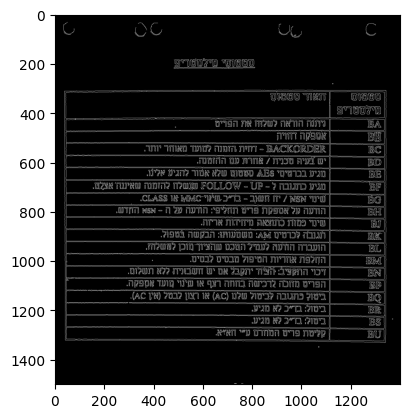

In [127]:
def draw_hough_lines(img, lines, color=(0, 255, 0), thickness=2):
    """
    Draws lines given in rho, theta format on an image.
    """
    if lines is None:
        return img
    img_copy = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2RGB)
    for line in lines:
        rho, theta = line['rho'], line['theta']
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(img_copy, pt1, pt2, color, thickness, cv2.LINE_AA)
    return img_copy

strongest_lines = find_vertical_lines(canny_img)
strongest_lines_img = draw_hough_lines(canny_img, strongest_lines)
plt.imshow(strongest_lines_img)


In [92]:
table_recognitions, table_bbox_coordinates = run_table_recognition(preprocessed_images_for_table_rec, layout_result)

Recognizing tables: 100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


## Convert To PDF

In [93]:
from pipeline.pdf_utils import create_pdf
from pipeline.preprocess import DEFAULT_PAGE_LIMITS

In [103]:
top_left_x, top_left_y, bottom_right_x, bottom_right_y = DEFAULT_PAGE_LIMITS
w, h = bottom_right_x - top_left_x, bottom_right_y - top_left_y
create_pdf("samples_out.pdf", recognized_texts, table_recognitions, table_bbox_coordinates, w, h)

Created page 0
Created page 1
